# 🤖 AI Sales Intelligence Agent

## Tool-Augmented Business Analysis with Generative AI

An AI-powered sales intelligence system that combines Python-based
business calculations with a Large Language Model (LLM) to analyze
sales performance and generate actionable business recommendations.

### Project Capabilities

- Calculate sales growth and change
- Analyze revenue performance
- Identify business risks
- Identify opportunities
- Generate management recommendations
- Recommend KPIs for monitoring
- Separate quantitative facts from AI-generated interpretation

### Technology

Python | Pandas | Groq LLM | Generative AI | Business Analytics AI Sales Intelligence Agent

## Tool-Augmented Business Analysis with Generative AI

An AI-powered sales intelligence system that combines Python-based
business calculations with a Large Language Model (LLM) to analyze
sales performance and generate actionable business recommendations.

### Project Capabilities

- Calculate sales growth and change
- Analyze revenue performance
- Identify business risks
- Identify opportunities
- Generate management recommendations
- Recommend KPIs for monitoring
- Separate quantitative facts from AI-generated interpretation

### Technology

Python | Pandas | Groq LLM | Generative AI | Business Analytics

## 🎯 Business Problem

Sales teams often have large amounts of performance data but limited
time to convert those numbers into useful business decisions.

The objective of this project is to build an AI Sales Intelligence Agent
that can:

1. Analyze sales performance
2. Calculate important business metrics
3. Explain performance changes
4. Identify potential risks
5. Suggest business actions
6. Recommend KPIs for management monitoring

The system combines deterministic Python calculations with Generative AI
so that numerical results are calculated programmatically before the LLM
interprets them.

## 🧠 Agent Architecture

The system follows a tool-augmented AI architecture.

**Input → Tools → Metrics → LLM → Business Intelligence**

Python tools are responsible for numerical calculations.

The LLM is responsible for:

- interpretation
- diagnosis
- risk identification
- opportunity identification
- recommendations
- KPI suggestions

This prevents the model from being responsible for basic arithmetic.

In [1]:
%pip install groq pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from getpass import getpass
import json
import os

print("Core libraries imported successfully.")

Core libraries imported successfully.


## 🔐 Secure API Configuration

The API key is intentionally requested at runtime.

It is not stored in this notebook and must never be committed to GitHub.

In [3]:
from getpass import getpass

GROQ_API_KEY = getpass("Enter your Groq API Key: ")

if not GROQ_API_KEY.strip():
    raise ValueError("Groq API key was not provided.")

print("API key received securely.")

Enter your Groq API Key:  ········


API key received securely.


In [4]:
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

print("Groq client initialized successfully.")

Groq client initialized successfully.


## 📊 Business Data

For this portfolio demonstration, we create a small business dataset.

The structure can later be replaced by CSV, Excel, database, CRM,
or ERP data without changing the core analysis tools.

In [5]:
sales_data = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Units Sold",
        "Average Order Value",
        "Customer Acquisition Cost",
        "Conversion Rate",
        "Gross Margin"
    ],
    "Previous_Period": [
        125000,
        2500,
        50.00,
        32.00,
        3.80,
        42.00
    ],
    "Current_Period": [
        145000,
        2700,
        53.70,
        35.00,
        4.20,
        40.50
    ]
})

sales_data

,Metric,Previous_Period,Current_Period
0,Revenue,125000.0,145000.0
1,Units Sold,2500.0,2700.0
2,Average Order Value,50.0,53.7
3,Customer Acquisition Cost,32.0,35.0
4,Conversion Rate,3.8,4.2
5,Gross Margin,42.0,40.5


## Business Sales Scenario

The following scenario represents a sales organization comparing two
consecutive periods.

The scenario intentionally includes multiple business indicators so the
agent can reason about revenue, volume, conversion, customer acquisition
cost, and average order value.

In [6]:
scenario_data = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Units Sold",
        "Average Order Value",
        "Customer Acquisition Cost",
        "Conversion Rate",
        "Returning Customer Rate"
    ],
    "Previous_Period": [
        125000,
        2500,
        50.00,
        32.00,
        3.80,
        41.00
    ],
    "Current_Period": [
        145000,
        2700,
        53.70,
        35.00,
        4.20,
        46.00
    ]
})

scenario_data

,Metric,Previous_Period,Current_Period
0,Revenue,125000.0,145000.0
1,Units Sold,2500.0,2700.0
2,Average Order Value,50.0,53.7
3,Customer Acquisition Cost,32.0,35.0
4,Conversion Rate,3.8,4.2
5,Returning Customer Rate,41.0,46.0


### Calculate business KPIs

In [7]:
def calculate_kpi_summary(data):
    """
    Calculate change and growth for all business metrics.
    """

    result = data.copy()

    result["Absolute_Change"] = (
        result["Current_Period"]
        - result["Previous_Period"]
    )

    result["Growth_Rate_%"] = np.where(
        result["Previous_Period"] != 0,
        (
            (
                result["Current_Period"]
                - result["Previous_Period"]
            )
            / result["Previous_Period"]
        ) * 100,
        np.nan
    )

    return result

In [8]:
kpi_summary = calculate_kpi_summary(
    scenario_data
)

kpi_summary.round(2)

,Metric,Previous_Period,Current_Period,Absolute_Change,Growth_Rate_%
0,Revenue,125000.0,145000.0,20000.0,16.00
1,Units Sold,2500.0,2700.0,200.0,8.00
2,Average Order Value,50.0,53.7,3.7,7.40
3,Customer Acquisition Cost,32.0,35.0,3.0,9.38
4,Conversion Rate,3.8,4.2,0.4,10.53
5,Returning Customer Rate,41.0,46.0,5.0,12.20


## 📊 KPI Dashboard

The dashboard provides a compact view of changes in the major commercial
indicators before the AI interpretation layer is applied.

In [9]:
kpi_summary_display = kpi_summary[
    [
        "Metric",
        "Previous_Period",
        "Current_Period",
        "Absolute_Change",
        "Growth_Rate_%"
    ]
].copy()

kpi_summary_display.round(2)

,Metric,Previous_Period,Current_Period,Absolute_Change,Growth_Rate_%
0,Revenue,125000.0,145000.0,20000.0,16.00
1,Units Sold,2500.0,2700.0,200.0,8.00
2,Average Order Value,50.0,53.7,3.7,7.40
3,Customer Acquisition Cost,32.0,35.0,3.0,9.38
4,Conversion Rate,3.8,4.2,0.4,10.53
5,Returning Customer Rate,41.0,46.0,5.0,12.20


In [10]:
from pathlib import Path

FIGURE_DIR = Path("C:/Users/Dell/Downloads/DSAI-Portfolio/""03-ai-sales-intelligence-agent/outputs/figures")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory:", FIGURE_DIR.resolve())

Figure directory: C:\Users\Dell\Downloads\DSAI-Portfolio\03-ai-sales-intelligence-agent\outputs\figures


### Create a growth visualization

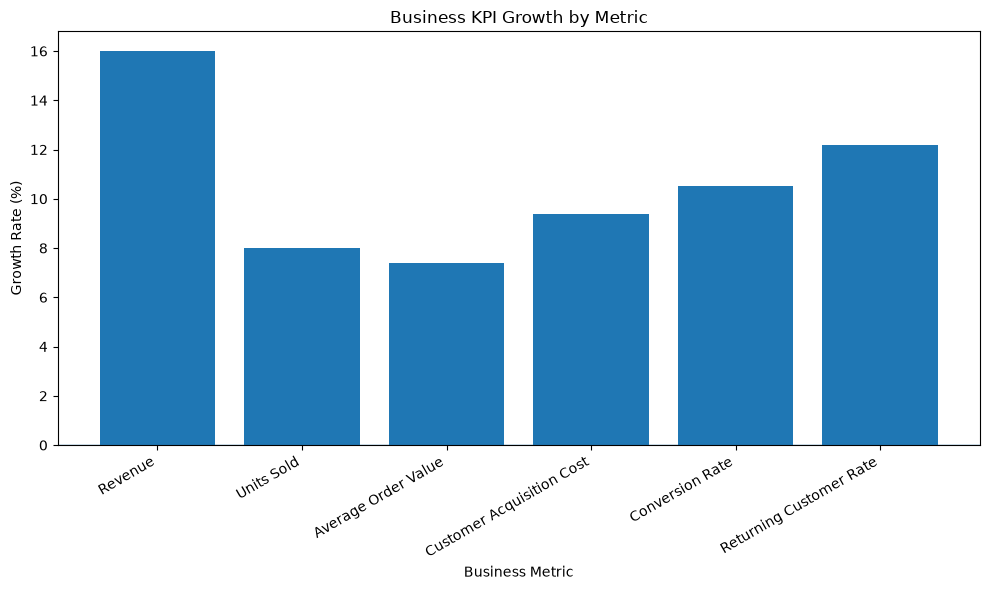

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    kpi_summary["Metric"],
    kpi_summary["Growth_Rate_%"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Business KPI Growth by Metric")
plt.xlabel("Business Metric")
plt.ylabel("Growth Rate (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "business-kpi-growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
def build_sales_intelligence_context(kpi_summary):
    """
    Build structured business context for the AI agent.
    """

    context = []

    for _, row in kpi_summary.iterrows():

        context.append({
            "metric": row["Metric"],
            "previous_period": round(
                float(row["Previous_Period"]), 2
            ),
            "current_period": round(
                float(row["Current_Period"]), 2
            ),
            "absolute_change": round(
                float(row["Absolute_Change"]), 2
            ),
            "growth_rate_percent": round(
                float(row["Growth_Rate_%"]), 2
            )
        })

    return context

In [13]:
sales_context = build_sales_intelligence_context(
    kpi_summary
)

sales_context

[{'metric': 'Revenue',
  'previous_period': 125000.0,
  'current_period': 145000.0,
  'absolute_change': 20000.0,
  'growth_rate_percent': 16.0},
 {'metric': 'Units Sold',
  'previous_period': 2500.0,
  'current_period': 2700.0,
  'absolute_change': 200.0,
  'growth_rate_percent': 8.0},
 {'metric': 'Average Order Value',
  'previous_period': 50.0,
  'current_period': 53.7,
  'absolute_change': 3.7,
  'growth_rate_percent': 7.4},
 {'metric': 'Customer Acquisition Cost',
  'previous_period': 32.0,
  'current_period': 35.0,
  'absolute_change': 3.0,
  'growth_rate_percent': 9.38},
 {'metric': 'Conversion Rate',
  'previous_period': 3.8,
  'current_period': 4.2,
  'absolute_change': 0.4,
  'growth_rate_percent': 10.53},
 {'metric': 'Returning Customer Rate',
  'previous_period': 41.0,
  'current_period': 46.0,
  'absolute_change': 5.0,
  'growth_rate_percent': 12.2}]

## 🧮 Sales Analysis Tools

The following Python functions form the quantitative tool layer of the
AI agent.

These calculations are deterministic and reproducible.

In [14]:
def calculate_change(previous, current):
    """
    Calculate absolute change between two values.
    """
    return current - previous


def calculate_growth_rate(previous, current):
    """
    Calculate percentage growth rate.
    """
    if previous == 0:
        return np.nan

    return ((current - previous) / previous) * 100


def calculate_metrics(data):
    """
    Calculate business performance metrics from the sales dataset.
    """

    results = {}

    for _, row in data.iterrows():

        metric = row["Metric"]
        previous = row["Previous_Period"]
        current = row["Current_Period"]

        results[metric] = {
            "previous": float(previous),
            "current": float(current),
            "change": float(calculate_change(previous, current)),
            "growth_rate_percent": float(
                calculate_growth_rate(previous, current)
            )
        }

    return results

In [15]:
metrics = calculate_metrics(sales_data)

metrics

{'Revenue': {'previous': 125000.0,
  'current': 145000.0,
  'change': 20000.0,
  'growth_rate_percent': 16.0},
 'Units Sold': {'previous': 2500.0,
  'current': 2700.0,
  'change': 200.0,
  'growth_rate_percent': 8.0},
 'Average Order Value': {'previous': 50.0,
  'current': 53.7,
  'change': 3.700000000000003,
  'growth_rate_percent': 7.400000000000005},
 'Customer Acquisition Cost': {'previous': 32.0,
  'current': 35.0,
  'change': 3.0,
  'growth_rate_percent': 9.375},
 'Conversion Rate': {'previous': 3.8,
  'current': 4.2,
  'change': 0.40000000000000036,
  'growth_rate_percent': 10.526315789473696},
 'Gross Margin': {'previous': 42.0,
  'current': 40.5,
  'change': -1.5,
  'growth_rate_percent': -3.571428571428571}}

In [16]:
# Convert the calculated metrics into a business-friendly table

metrics_table = sales_data.copy()

metrics_table["Change"] = (
    metrics_table["Current_Period"]
    - metrics_table["Previous_Period"]
)

metrics_table["Growth_Rate_%"] = (
    (
        metrics_table["Current_Period"]
        - metrics_table["Previous_Period"]
    )
    / metrics_table["Previous_Period"]
) * 100

metrics_table

,Metric,Previous_Period,Current_Period,Change,Growth_Rate_%
0,Revenue,125000.0,145000.0,20000.0,16.000000
1,Units Sold,2500.0,2700.0,200.0,8.000000
2,Average Order Value,50.0,53.7,3.7,7.400000
3,Customer Acquisition Cost,32.0,35.0,3.0,9.375000
4,Conversion Rate,3.8,4.2,0.4,10.526316
5,Gross Margin,42.0,40.5,-1.5,-3.571429


## 📈 Revenue Performance

Revenue is one of the most important commercial indicators.

The agent uses the Python calculation rather than asking the LLM
to perform the arithmetic itself.

In [17]:
revenue_previous = sales_data.loc[
    sales_data["Metric"] == "Revenue",
    "Previous_Period"
].iloc[0]

revenue_current = sales_data.loc[
    sales_data["Metric"] == "Revenue",
    "Current_Period"
].iloc[0]

revenue_change = calculate_change(
    revenue_previous,
    revenue_current
)

revenue_growth = calculate_growth_rate(
    revenue_previous,
    revenue_current
)

print(f"Previous Revenue: ${revenue_previous:,.2f}")
print(f"Current Revenue: ${revenue_current:,.2f}")
print(f"Revenue Change: ${revenue_change:,.2f}")
print(f"Revenue Growth: {revenue_growth:.2f}%")

Previous Revenue: $125,000.00
Current Revenue: $145,000.00
Revenue Change: $20,000.00
Revenue Growth: 16.00%


## 📊 Sales Performance Visualization

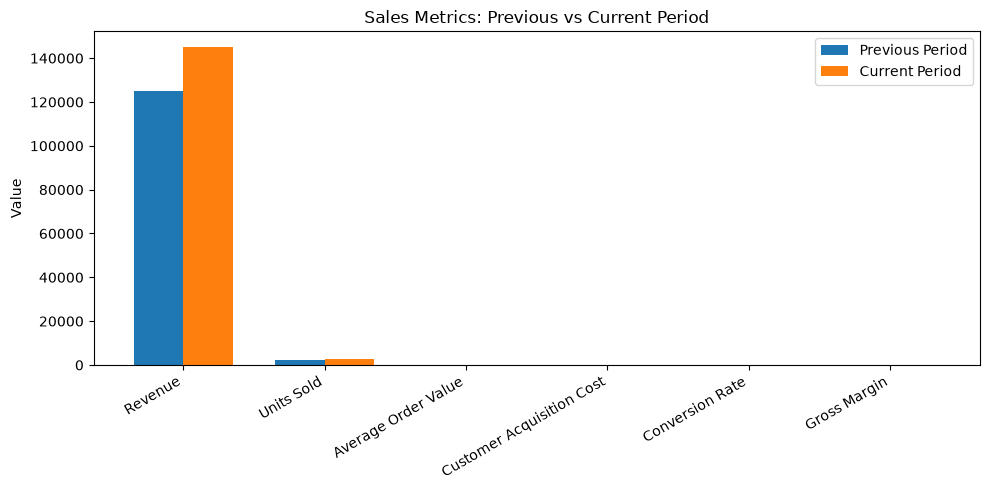

In [18]:
plt.figure(figsize=(10, 5))

x = np.arange(len(sales_data))
width = 0.35

plt.bar(
    x - width / 2,
    sales_data["Previous_Period"],
    width,
    label="Previous Period"
)

plt.bar(
    x + width / 2,
    sales_data["Current_Period"],
    width,
    label="Current Period"
)

plt.xticks(
    x,
    sales_data["Metric"],
    rotation=30,
    ha="right"
)

plt.title("Sales Metrics: Previous vs Current Period")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()

plt.show()

In [19]:
# Create output directory

from pathlib import Path

FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory:", FIGURE_DIR.resolve())

Figure directory: C:\Users\Dell\Downloads\DSAI-Portfolio\03-ai-sales-intelligence-agent\outputs\figures


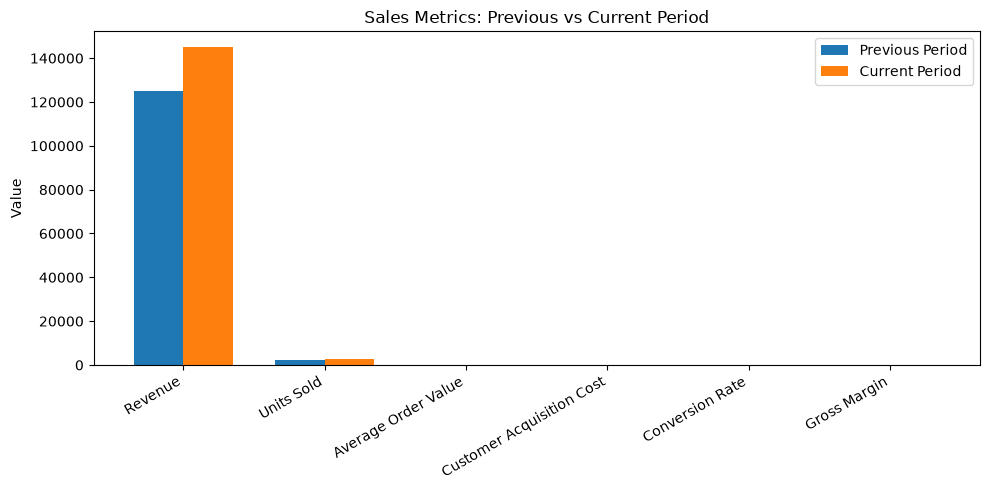

In [20]:
# Save the main comparison figure

plt.figure(figsize=(10, 5))

x = np.arange(len(sales_data))
width = 0.35

plt.bar(
    x - width / 2,
    sales_data["Previous_Period"],
    width,
    label="Previous Period"
)

plt.bar(
    x + width / 2,
    sales_data["Current_Period"],
    width,
    label="Current Period"
)

plt.xticks(
    x,
    sales_data["Metric"],
    rotation=30,
    ha="right"
)

plt.title("Sales Metrics: Previous vs Current Period")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "sales-metrics-comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 🛠️ AI Agent Tools

The agent can access structured business-analysis tools.

Available tools:

1. `calculate_sales_growth`
2. `calculate_sales_change`
3. `get_sales_summary`

In [21]:
def calculate_sales_growth(previous, current):
    """
    Calculate percentage growth between two periods.
    """

    if previous == 0:
        return {
            "growth_rate_percent": None,
            "message": "Growth cannot be calculated because previous value is zero."
        }

    growth = ((current - previous) / previous) * 100

    return {
        "previous_value": previous,
        "current_value": current,
        "growth_rate_percent": round(growth, 2)
    }


def calculate_sales_change(previous, current):
    """
    Calculate absolute change between two periods.
    """

    change = current - previous

    return {
        "previous_value": previous,
        "current_value": current,
        "absolute_change": round(change, 2)
    }


def get_sales_summary():
    """
    Return the complete calculated sales summary.
    """

    return calculate_metrics(sales_data)

## 📊 KPI Diagnosis

The KPI diagnosis table compares the previous and current periods and
classifies each metric according to its business direction.

A positive change is not automatically considered good. For example,
an increase in Customer Acquisition Cost is unfavorable, while an increase
in Revenue is favorable.

In [22]:
def classify_kpi_change(metric, previous, current):
    """
    Classify a KPI movement as positive, negative, or neutral
    based on the business meaning of the metric.
    """

    change = current - previous

    higher_is_better = {
        "Revenue": True,
        "Units Sold": True,
        "Average Order Value": True,
        "Conversion Rate": True,
        "Gross Margin": True,
        "Customer Acquisition Cost": False
    }

    if metric not in higher_is_better:
        return "Unknown"

    if change > 0:
        return "Positive" if higher_is_better[metric] else "Negative"

    if change < 0:
        return "Negative" if higher_is_better[metric] else "Positive"

    return "Neutral"

In [23]:
kpi_diagnosis = sales_data.copy()

kpi_diagnosis["Change"] = (
    kpi_diagnosis["Current_Period"]
    - kpi_diagnosis["Previous_Period"]
)

kpi_diagnosis["Growth_Rate_%"] = (
    kpi_diagnosis["Change"]
    / kpi_diagnosis["Previous_Period"]
) * 100

kpi_diagnosis["Business_Direction"] = [
    classify_kpi_change(
        row["Metric"],
        row["Previous_Period"],
        row["Current_Period"]
    )
    for _, row in kpi_diagnosis.iterrows()
]

kpi_diagnosis.round(2)

,Metric,Previous_Period,Current_Period,Change,Growth_Rate_%,Business_Direction
0,Revenue,125000.0,145000.0,20000.0,16.00,Positive
1,Units Sold,2500.0,2700.0,200.0,8.00,Positive
2,Average Order Value,50.0,53.7,3.7,7.40,Positive
3,Customer Acquisition Cost,32.0,35.0,3.0,9.38,Negative
4,Conversion Rate,3.8,4.2,0.4,10.53,Positive
5,Gross Margin,42.0,40.5,-1.5,-3.57,Negative


In [24]:
def calculate_business_health_score(diagnosis):
    """
    Calculate a simple KPI health score.

    Positive KPI movement = +1
    Negative KPI movement = -1
    Neutral = 0
    """

    score_map = {
        "Positive": 1,
        "Negative": -1,
        "Neutral": 0
    }

    score = diagnosis["Business_Direction"].map(
        score_map
    ).sum()

    return score

In [25]:
health_score = calculate_business_health_score(
    kpi_diagnosis
)

print("Business Health Score:", health_score)

Business Health Score: 2


In [26]:
# Test the tools before connecting them to the LLM

print(
    calculate_sales_growth(
        revenue_previous,
        revenue_current
    )
)

print(
    calculate_sales_change(
        revenue_previous,
        revenue_current
    )
)

{'previous_value': np.float64(125000.0), 'current_value': np.float64(145000.0), 'growth_rate_percent': np.float64(16.0)}
{'previous_value': np.float64(125000.0), 'current_value': np.float64(145000.0), 'absolute_change': np.float64(20000.0)}


## 🤖 AI Sales Intelligence Agent

The LLM receives verified business metrics and converts them into
management-oriented insights.

The agent must clearly distinguish:

### FACTS
Numbers calculated by Python.

### INTERPRETATION
What those numbers may indicate.

### HYPOTHESES
Potential business explanations that require validation.

### RECOMMENDATIONS
Actions management could consider.

In [27]:
def create_business_context(metrics):
    """
    Convert calculated metrics into structured context for the LLM.
    """

    return json.dumps(
        metrics,
        indent=2
    )

In [28]:
business_context = {
    "sales_metrics": metrics,
    "kpi_diagnosis": kpi_diagnosis.to_dict(orient="records"),
    "business_health_score": float(health_score)
}

business_context = json.dumps(
    business_context,
    indent=2,
    default=lambda x: x.item() if hasattr(x, "item") else str(x)
)

print(business_context)

{
  "sales_metrics": {
    "Revenue": {
      "previous": 125000.0,
      "current": 145000.0,
      "change": 20000.0,
      "growth_rate_percent": 16.0
    },
    "Units Sold": {
      "previous": 2500.0,
      "current": 2700.0,
      "change": 200.0,
      "growth_rate_percent": 8.0
    },
    "Average Order Value": {
      "previous": 50.0,
      "current": 53.7,
      "change": 3.700000000000003,
      "growth_rate_percent": 7.400000000000005
    },
    "Customer Acquisition Cost": {
      "previous": 32.0,
      "current": 35.0,
      "change": 3.0,
      "growth_rate_percent": 9.375
    },
    "Conversion Rate": {
      "previous": 3.8,
      "current": 4.2,
      "change": 0.40000000000000036,
      "growth_rate_percent": 10.526315789473696
    },
    "Gross Margin": {
      "previous": 42.0,
      "current": 40.5,
      "change": -1.5,
      "growth_rate_percent": -3.571428571428571
    }
  },
  "kpi_diagnosis": [
    {
      "Metric": "Revenue",
      "Previous_Period": 1250

In [29]:
SYSTEM_PROMPT = """
You are an AI Sales Intelligence Agent supporting business managers.

You analyze verified business metrics and convert them into actionable
sales intelligence.

RULES:

1. Treat Python-calculated metrics as the numerical source of truth.
2. Never invent numbers.
3. Separate FACTS from INTERPRETATION.
4. Clearly label possible explanations as HYPOTHESES.
5. Do not present hypotheses as confirmed causes.
6. Identify both risks and opportunities.
7. Prioritize recommendations by business impact.
8. Recommend measurable KPIs.
9. When regional data is available, compare regions.
10. Identify regions requiring attention.
11. Consider both revenue growth and order growth.
12. Explain when revenue growth may be driven by changes in average
    order value rather than order volume.

Return the analysis using this structure:

## 1. Executive Summary

## 2. Key Performance Facts

## 3. Regional Performance

## 4. Performance Diagnosis

## 5. Potential Causes / Hypotheses

## 6. Business Risks

## 7. Business Opportunities

## 8. Recommended Actions

## 9. KPIs to Monitor
"""

In [30]:
# Check which models are available to the authenticated Groq account

available_models = client.models.list()

model_ids = [
    model.id
    for model in available_models.data
]

print("Available Groq models:")
for model_id in model_ids:
    print("-", model_id)

Available Groq models:
- allam-2-7b
- meta-llama/llama-prompt-guard-2-22m
- openai/gpt-oss-120b
- groq/compound-mini
- openai/gpt-oss-20b
- canopylabs/orpheus-v1-english
- groq/compound
- meta-llama/llama-prompt-guard-2-86m
- canopylabs/orpheus-arabic-saudi
- whisper-large-v3
- whisper-large-v3-turbo
- openai/gpt-oss-safeguard-20b
- qwen/qwen3.6-27b


In [31]:
preferred_models = [
    "llama-3.3-70b-versatile",
    "openai/gpt-oss-120b",
    "openai/gpt-oss-20b",
    "llama-3.1-8b-instant"
]

MODEL_NAME = next(
    (
        model
        for model in preferred_models
        if model in model_ids
    ),
    None
)

if MODEL_NAME is None:
    raise RuntimeError(
        "No supported text-generation model was found "
        "for this Groq API key."
    )

print("Selected model:", MODEL_NAME)

Selected model: openai/gpt-oss-120b


In [32]:
def run_sales_intelligence_agent(
    sales_context,
    model_name=MODEL_NAME
):
    
    user_prompt = f"""
Analyze the following verified business metrics.

{sales_context}

Provide a management-oriented sales intelligence report using this structure:

1. Executive Summary
2. Key Performance Facts
3. Performance Diagnosis
4. Potential Causes / Hypotheses
5. Business Risks
6. Business Opportunities
7. Recommended Actions
8. KPIs to Monitor

Rules:
- Do not invent numerical values.
- Use the supplied metrics as the source of truth.
- Clearly distinguish facts from hypotheses.
- Do not present hypotheses as proven causes.
- Recommendations should be practical and measurable.
"""

    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ],
        temperature=0.2,
        max_tokens=2200
    )

    return response.choices[0].message.content

In [33]:
test_response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": "Respond with exactly: Groq model connection successful."
        }
    ],
    temperature=0,
    max_tokens=50
)

print(test_response.choices[0].message.content)

Groq model connection successful.


In [34]:
agent_report = run_sales_intelligence_agent(
    business_context
)

print(agent_report)

**Sales Intelligence Report**  
*Prepared for Business Management*  

---

## 1. Executive Summary
- **Revenue** grew **16 %** ( +$20 k ) to **$145 k**.  
- **Units sold** rose **8 %** ( +200 ) to **2 700** units.  
- **Average Order Value (AOV)** increased **7.4 %** to **$53.7**.  
- **Conversion rate** improved **10.5 %** to **4.2 %**.  
- **Customer Acquisition Cost (CAC)** climbed **9.4 %** to **$35** per new customer.  
- **Gross margin** slipped **3.6 %** (‑1.5 pp) to **40.5 %**.  

Overall, top‑line growth is solid, driven by both higher volume and higher AOV. However, rising CAC and a declining gross margin are eroding profitability, reflected in a low **Business Health Score of 2.0**. Immediate focus should be on protecting margin while sustaining acquisition efficiency.

---

## 2. Key Performance Facts
| Metric | Previous | Current | Δ (Absolute) | Δ (%) | Direction |
|--------|----------|---------|--------------|-------|-----------|
| **Revenue** | $125 000 | $145 000 | +$2

## Regional Sales Intelligence

To demonstrate how the agent can work with operational business data,
the analysis is extended from an overall sales summary to regional
performance data.

This allows the system to identify differences between markets and
generate more targeted recommendations.

In [35]:
regional_sales = pd.DataFrame({
    "Region": [
        "North",
        "South",
        "East",
        "West"
    ],
    "Previous_Revenue": [
        32000,
        28000,
        30000,
        35000
    ],
    "Current_Revenue": [
        38500,
        27000,
        34500,
        45000
    ],
    "Previous_Orders": [
        640,
        590,
        610,
        660
    ],
    "Current_Orders": [
        710,
        560,
        650,
        760
    ]
})

regional_sales

,Region,Previous_Revenue,Current_Revenue,Previous_Orders,Current_Orders
0,North,32000,38500,640,710
1,South,28000,27000,590,560
2,East,30000,34500,610,650
3,West,35000,45000,660,760


In [36]:
regional_sales["Revenue_Change"] = (
    regional_sales["Current_Revenue"]
    - regional_sales["Previous_Revenue"]
)

regional_sales["Revenue_Growth_%"] = (
    regional_sales["Revenue_Change"]
    / regional_sales["Previous_Revenue"]
) * 100

regional_sales["Order_Change"] = (
    regional_sales["Current_Orders"]
    - regional_sales["Previous_Orders"]
)

regional_sales["Order_Growth_%"] = (
    regional_sales["Order_Change"]
    / regional_sales["Previous_Orders"]
) * 100

regional_sales["Current_AOV"] = (
    regional_sales["Current_Revenue"]
    / regional_sales["Current_Orders"]
)

regional_sales.round(2)

,Region,Previous_Revenue,Current_Revenue,Previous_Orders,Current_Orders,Revenue_Change,Revenue_Growth_%,Order_Change,Order_Growth_%,Current_AOV
0,North,32000,38500,640,710,6500,20.31,70,10.94,54.23
1,South,28000,27000,590,560,-1000,-3.57,-30,-5.08,48.21
2,East,30000,34500,610,650,4500,15.00,40,6.56,53.08
3,West,35000,45000,660,760,10000,28.57,100,15.15,59.21


### Regional Revenue Growth

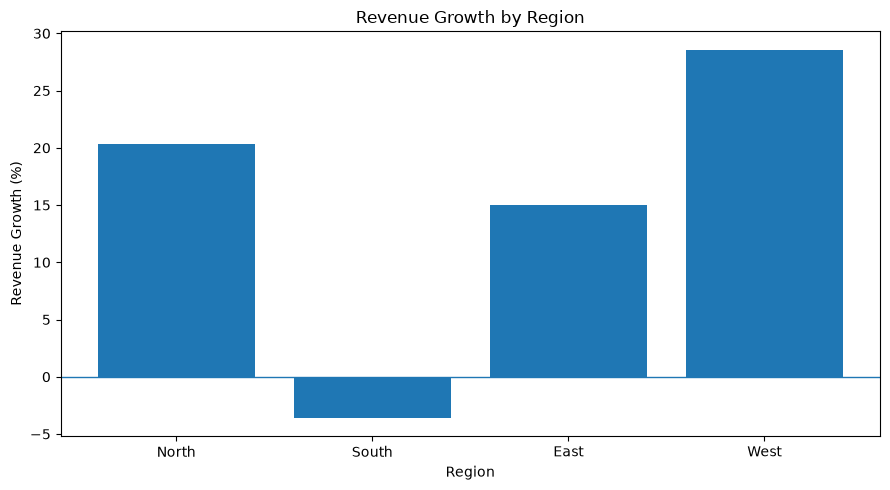

In [37]:
plt.figure(figsize=(9, 5))

plt.bar(
    regional_sales["Region"],
    regional_sales["Revenue_Growth_%"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Revenue Growth by Region")
plt.xlabel("Region")
plt.ylabel("Revenue Growth (%)")

plt.tight_layout()
plt.show()

In [38]:
# Ensure output directory exists

from pathlib import Path

FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figure directory:", FIGURE_DIR.resolve())

Figure directory: C:\Users\Dell\Downloads\DSAI-Portfolio\03-ai-sales-intelligence-agent\outputs\figures


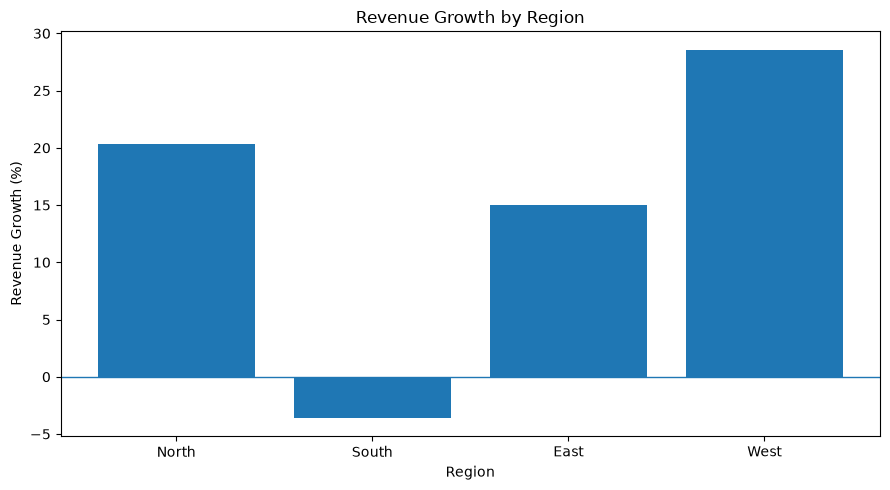

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(
    regional_sales["Region"],
    regional_sales["Revenue_Growth_%"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Revenue Growth by Region")
plt.xlabel("Region")
plt.ylabel("Revenue Growth (%)")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "regional-revenue-growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Regional Analysis Tool

The regional performance tool converts calculated regional KPIs into
structured information that can be supplied to the AI agent.

In [40]:
def get_regional_sales_summary(data):
    """
    Convert regional sales performance into structured information
    for the AI agent.
    """

    summary = []

    for _, row in data.iterrows():

        summary.append({
            "region": row["Region"],
            "revenue_growth_percent": round(
                row["Revenue_Growth_%"], 2
            ),
            "order_growth_percent": round(
                row["Order_Growth_%"], 2
            ),
            "current_average_order_value": round(
                row["Current_AOV"], 2
            )
        })

    return summary

In [41]:
regional_context = get_regional_sales_summary(
    regional_sales
)

regional_context

[{'region': 'North',
  'revenue_growth_percent': 20.31,
  'order_growth_percent': 10.94,
  'current_average_order_value': 54.23},
 {'region': 'South',
  'revenue_growth_percent': -3.57,
  'order_growth_percent': -5.08,
  'current_average_order_value': 48.21},
 {'region': 'East',
  'revenue_growth_percent': 15.0,
  'order_growth_percent': 6.56,
  'current_average_order_value': 53.08},
 {'region': 'West',
  'revenue_growth_percent': 28.57,
  'order_growth_percent': 15.15,
  'current_average_order_value': 59.21}]

In [42]:
combined_business_context = {
    "overall_sales_metrics": metrics,
    "regional_performance": regional_context
}

combined_business_context_json = json.dumps(
    combined_business_context,
    indent=2
)

print(combined_business_context_json)

{
  "overall_sales_metrics": {
    "Revenue": {
      "previous": 125000.0,
      "current": 145000.0,
      "change": 20000.0,
      "growth_rate_percent": 16.0
    },
    "Units Sold": {
      "previous": 2500.0,
      "current": 2700.0,
      "change": 200.0,
      "growth_rate_percent": 8.0
    },
    "Average Order Value": {
      "previous": 50.0,
      "current": 53.7,
      "change": 3.700000000000003,
      "growth_rate_percent": 7.400000000000005
    },
    "Customer Acquisition Cost": {
      "previous": 32.0,
      "current": 35.0,
      "change": 3.0,
      "growth_rate_percent": 9.375
    },
    "Conversion Rate": {
      "previous": 3.8,
      "current": 4.2,
      "change": 0.40000000000000036,
      "growth_rate_percent": 10.526315789473696
    },
    "Gross Margin": {
      "previous": 42.0,
      "current": 40.5,
      "change": -1.5,
      "growth_rate_percent": -3.571428571428571
    }
  },
  "regional_performance": [
    {
      "region": "North",
      "revenue_g

### Business insight layer

In [43]:
def generate_deterministic_insights(kpi_summary):

    insights = []

    for _, row in kpi_summary.iterrows():

        metric = row["Metric"]
        growth = row["Growth_Rate_%"]

        if growth > 0:
            insights.append(
                f"{metric} increased by {growth:.2f}%."
            )

        elif growth < 0:
            insights.append(
                f"{metric} decreased by {abs(growth):.2f}%."
            )

        else:
            insights.append(
                f"{metric} remained unchanged."
            )

    return insights

In [44]:
deterministic_insights = generate_deterministic_insights(
    kpi_summary
)

for insight in deterministic_insights:
    print("-", insight)

- Revenue increased by 16.00%.
- Units Sold increased by 8.00%.
- Average Order Value increased by 7.40%.
- Customer Acquisition Cost increased by 9.38%.
- Conversion Rate increased by 10.53%.
- Returning Customer Rate increased by 12.20%.


In [45]:
def run_sales_intelligence_agent(business_context):

    user_prompt = f"""
Analyze the following verified sales intelligence data:

{business_context}

Focus on:

- overall performance
- regional differences
- revenue growth
- order growth
- average order value
- risks
- opportunities
- practical business actions

Do not invent information that is not present in the supplied data.
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": user_prompt
            }
        ],
        temperature=0.2,
        max_tokens=2200
    )

    return response.choices[0].message.content

## AI Regional Sales Intelligence Report

In [46]:
final_business_context = json.dumps(
    combined_business_context,
    indent=2
)

final_agent_report = run_sales_intelligence_agent(
    final_business_context
)

print(final_agent_report)

## 1. Executive Summary  
The business achieved a **16 % revenue increase** to $145 k, driven by an **8 % rise in units sold** and a **7.4 % lift in average order value (AOV)**. Gross margin slipped 3.6 % (from 42 % to 40.5 %), while customer acquisition cost (CAC) rose 9.4 %. Conversion improved by 10.5 %. Regionally, the **West** and **North** markets outperformed, whereas the **South** lagged behind with negative revenue and order growth. The key risk is margin erosion; the primary opportunity lies in scaling high‑AOV regions and optimizing CAC.

---

## 2. Key Performance Facts  

| Metric | Previous | Current | Change | Growth Rate |
|--------|----------|---------|--------|-------------|
| **Revenue** | $125 k | $145 k | +$20 k | **+16 %** |
| **Units Sold** | 2 500 | 2 700 | +200 | **+8 %** |
| **Average Order Value** | $50.00 | $53.70 | +$3.70 | **+7.4 %** |
| **Customer Acquisition Cost** | $32.00 | $35.00 | +$3.00 | **+9.4 %** |
| **Conversion Rate** | 3.8 % | 4.2 % | +0.4 % |

## Executive KPI Summary

In [47]:
executive_kpis = pd.DataFrame({
    "KPI": [
        "Overall Revenue Growth",
        "Overall Units Sold Growth",
        "Overall AOV Growth",
        "Overall CAC Growth",
        "Overall Conversion Rate Growth"
    ],
    "Value": [
        calculate_growth_rate(125000, 145000),
        calculate_growth_rate(2500, 2700),
        calculate_growth_rate(50, 53.70),
        calculate_growth_rate(32, 35),
        calculate_growth_rate(3.8, 4.2)
    ]
})

executive_kpis["Value"] = executive_kpis["Value"].round(2)

executive_kpis

,KPI,Value
0,Overall Revenue Growth,16.00
1,Overall Units Sold Growth,8.00
2,Overall AOV Growth,7.40
3,Overall CAC Growth,9.38
4,Overall Conversion Rate Growth,10.53


## AI Output Validation

The generated report is checked for the expected business-analysis
sections. This provides a basic structural quality check for the
Generative AI output.

In [48]:
required_sections = [
    "Executive Summary",
    "Key Performance Facts",
    "Regional Performance",
    "Performance Diagnosis",
    "Potential Causes",
    "Business Risks",
    "Business Opportunities",
    "Recommended Actions",
    "KPIs to Monitor"
]

section_check = {
    section: section.lower() in final_agent_report.lower()
    for section in required_sections
}

section_check

{'Executive Summary': True,
 'Key Performance Facts': True,
 'Regional Performance': True,
 'Performance Diagnosis': True,
 'Potential Causes': True,
 'Business Risks': True,
 'Business Opportunities': True,
 'Recommended Actions': True,
 'KPIs to Monitor': True}

In [49]:
print(
    "Sections detected:",
    sum(section_check.values()),
    "/",
    len(section_check)
)

for section, present in section_check.items():
    print(f"{'✓' if present else '✗'} {section}")

Sections detected: 9 / 9
✓ Executive Summary
✓ Key Performance Facts
✓ Regional Performance
✓ Performance Diagnosis
✓ Potential Causes
✓ Business Risks
✓ Business Opportunities
✓ Recommended Actions
✓ KPIs to Monitor


In [50]:
models = client.models.list()

for model in models.data:
    if model.active:
        print(model.id)

whisper-large-v3-turbo
openai/gpt-oss-120b
qwen/qwen3.6-27b
groq/compound-mini
canopylabs/orpheus-v1-english
whisper-large-v3
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-22m
openai/gpt-oss-safeguard-20b
canopylabs/orpheus-arabic-saudi
groq/compound
allam-2-7b
meta-llama/llama-prompt-guard-2-86m


In [51]:
# Check currently available Groq models

available_models = client.models.list()

model_ids = [
    model.id
    for model in available_models.data
    if getattr(model, "active", True)
]

print("Available active models:")
for model_id in model_ids:
    print("-", model_id)

Available active models:
- qwen/qwen3.6-27b
- whisper-large-v3
- groq/compound
- openai/gpt-oss-120b
- openai/gpt-oss-20b
- allam-2-7b
- whisper-large-v3-turbo
- groq/compound-mini
- meta-llama/llama-prompt-guard-2-86m
- meta-llama/llama-prompt-guard-2-22m
- openai/gpt-oss-safeguard-20b
- canopylabs/orpheus-v1-english
- canopylabs/orpheus-arabic-saudi


In [52]:
final_business_context = json.dumps(
    combined_business_context,
    indent=2
)

final_agent_report = run_sales_intelligence_agent(
    final_business_context
)

print(final_agent_report)

## 1. Executive Summary  
The company achieved a **+16 % revenue** increase to $145 k, driven by an **+8 % rise in units sold** and a **+7.4 % jump in average order value (AOV)**.  Conversion rates improved by **+10.5 %**, but the **gross margin fell 3.6 %** and the **customer‑acquisition cost (CAC) rose 9.4 %**.  Regionally, the **West** and **North** markets are outperforming, while the **South** is contracting.  The key risk is margin erosion and rising CAC, whereas the main opportunity lies in scaling high‑AOV, high‑growth regions and turning around the South.

---

## 2. Key Performance Facts  

| Metric | Previous | Current | Change | Growth Rate |
|--------|----------|---------|--------|-------------|
| **Revenue** | $125 k | $145 k | +$20 k | **+16 %** |
| **Units Sold** | 2 500 | 2 700 | +200 | **+8 %** |
| **Average Order Value** | $50.00 | $53.70 | +$3.70 | **+7.4 %** |
| **Customer Acquisition Cost** | $32.00 | $35.00 | +$3.00 | **+9.4 %** |
| **Conversion Rate** | 3.8 % | 

## 🔍 Business Interpretation

The agent should now transform quantitative calculations into:

- performance diagnosis
- possible business causes
- risks
- opportunities
- recommendations
- KPIs

The numerical calculations remain controlled by Python while the LLM
provides natural-language interpretation.

In [53]:
print("=" * 80)
print("AI SALES INTELLIGENCE REPORT")
print("=" * 80)

print(agent_report)

AI SALES INTELLIGENCE REPORT
**Sales Intelligence Report**  
*Prepared for Business Management*  

---

## 1. Executive Summary
- **Revenue** grew **16 %** ( +$20 k ) to **$145 k**.  
- **Units sold** rose **8 %** ( +200 ) to **2 700** units.  
- **Average Order Value (AOV)** increased **7.4 %** to **$53.7**.  
- **Conversion rate** improved **10.5 %** to **4.2 %**.  
- **Customer Acquisition Cost (CAC)** climbed **9.4 %** to **$35** per new customer.  
- **Gross margin** slipped **3.6 %** (‑1.5 pp) to **40.5 %**.  

Overall, top‑line growth is solid, driven by both higher volume and higher AOV. However, rising CAC and a declining gross margin are eroding profitability, reflected in a low **Business Health Score of 2.0**. Immediate focus should be on protecting margin while sustaining acquisition efficiency.

---

## 2. Key Performance Facts
| Metric | Previous | Current | Δ (Absolute) | Δ (%) | Direction |
|--------|----------|---------|--------------|-------|-----------|
| **Revenue*

## 📌 Management Decision Framework

The output can be used as a decision-support layer.

### Quantitative Layer
Python calculates:

- growth
- change
- current performance
- previous performance

### Intelligence Layer
The AI interprets:

- what changed
- why it might have changed
- what should be investigated
- what actions could be considered

### Monitoring Layer
The AI recommends:

- KPIs
- thresholds
- follow-up metrics

## ⚠️ Responsible AI Note

This system is a business decision-support tool.

AI-generated hypotheses and recommendations should be validated against
additional business information before operational decisions are made.

The model should not be treated as the sole source of truth.

## 🏁 Conclusion

This project demonstrates a tool-augmented Generative AI workflow for
sales intelligence.

The system combines:

- Python
- Pandas
- deterministic business calculations
- Generative AI
- LLM-based reasoning
- business recommendations
- KPI monitoring

The key design principle is that quantitative calculations are performed
programmatically, while Generative AI is used primarily for interpretation
and decision-support communication.

In [54]:
print("=" * 70)
print("FINAL PROJECT QA")
print("=" * 70)

print("\nDataset rows:", len(sales_data))
print("Dataset columns:", len(sales_data.columns))

print("\nRevenue Growth:")
print(f"{revenue_growth:.2f}%")

print("\nAvailable Tools:")
print("- calculate_sales_growth")
print("- calculate_sales_change")
print("- get_sales_summary")

print("\nAgent Report Generated:", bool(agent_report))

print("\nOutput Directory:")
for file in FIGURE_DIR.iterdir():
    print("-", file.name)

print("\nFINAL QA COMPLETE")

FINAL PROJECT QA

Dataset rows: 6
Dataset columns: 3

Revenue Growth:
16.00%

Available Tools:
- calculate_sales_growth
- calculate_sales_change
- get_sales_summary

Agent Report Generated: True

Output Directory:
- business-kpi-growth.png
- regional-revenue-growth.png
- sales-metrics-comparison.png

FINAL QA COMPLETE


In [55]:
print("=" * 70)
print("AI SALES INTELLIGENCE — FINAL QA")
print("=" * 70)

print("\nOverall Revenue Growth:")
print(f"{revenue_growth:.2f}%")

print("\nRegional Performance:")
print(
    regional_sales[
        [
            "Region",
            "Revenue_Growth_%",
            "Order_Growth_%",
            "Current_AOV"
        ]
    ].round(2)
)

print("\nAgent Report Generated:")
print(bool(final_agent_report))

print("\nAgent Sections Detected:")
print(
    sum(section_check.values()),
    "/",
    len(section_check)
)

print("\nOutput Figures:")

for file in FIGURE_DIR.iterdir():
    print("-", file.name)

print("\nFINAL QA COMPLETE")

AI SALES INTELLIGENCE — FINAL QA

Overall Revenue Growth:
16.00%

Regional Performance:
  Region  Revenue_Growth_%  Order_Growth_%  Current_AOV
0  North             20.31           10.94        54.23
1  South             -3.57           -5.08        48.21
2   East             15.00            6.56        53.08
3   West             28.57           15.15        59.21

Agent Report Generated:
True

Agent Sections Detected:
9 / 9

Output Figures:
- business-kpi-growth.png
- regional-revenue-growth.png
- sales-metrics-comparison.png

FINAL QA COMPLETE


In [56]:
print("=" * 80)
print("AI SALES INTELLIGENCE REPORT")
print("=" * 80)

print(agent_report)

AI SALES INTELLIGENCE REPORT
**Sales Intelligence Report**  
*Prepared for Business Management*  

---

## 1. Executive Summary
- **Revenue** grew **16 %** ( +$20 k ) to **$145 k**.  
- **Units sold** rose **8 %** ( +200 ) to **2 700** units.  
- **Average Order Value (AOV)** increased **7.4 %** to **$53.7**.  
- **Conversion rate** improved **10.5 %** to **4.2 %**.  
- **Customer Acquisition Cost (CAC)** climbed **9.4 %** to **$35** per new customer.  
- **Gross margin** slipped **3.6 %** (‑1.5 pp) to **40.5 %**.  

Overall, top‑line growth is solid, driven by both higher volume and higher AOV. However, rising CAC and a declining gross margin are eroding profitability, reflected in a low **Business Health Score of 2.0**. Immediate focus should be on protecting margin while sustaining acquisition efficiency.

---

## 2. Key Performance Facts
| Metric | Previous | Current | Δ (Absolute) | Δ (%) | Direction |
|--------|----------|---------|--------------|-------|-----------|
| **Revenue*